In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from matplotlib.colors import LogNorm

import richio
from richio import shockfinder as sf
import dev

## Load

Run `1.1-shock-finder-tde` first to produce the `.npz`.

In [2]:
snap_path = "/home/hey4/rich_tde/data/external/R0.47M0.5BH10000beta1S60Compton/snap_full_361.h5"
snap = richio.load(snap_path)
snap.time.in_units("day")

unyt_array([5.7621411], 'day')

In [3]:
results_path = "/home/hey4/rich_tde/data/interim/shockfinder_R0.47M0.5BH10000beta1S60Compton_361.npz"
data = np.load(results_path)

shock_zone = data["shock_zone"]
result = SimpleNamespace(
    surface_mask=data["surface_mask"],
    pre_mask=data["pre_mask"],
    post_mask=data["post_mask"],
    mach_T=data["mach_T"],
    mach_P=data["mach_P"],
    mach_rho=data["mach_rho"],
)
print(f"t = {float(data['time_day']):.3f} day")
print(f"{shock_zone.sum():,} shock-zone cells, {result.surface_mask.sum():,} surface cells")

t = 5.762 day
432,671 shock-zone cells, 234,832 surface cells


## Fields

In [ ]:
ax, im, _ = snap.plots.slice(
    "density",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"\rho",
)
plt.show()

In [ ]:
ax, im, _ = snap.plots.slice(
    "temperature",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"T",
    cmap="inferno",
)
plt.show()

In [ ]:
ax, im, _ = snap.plots.slice(
    "pressure",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"P",
    cmap="rainbow",
)
plt.show()

In [ ]:
ax, im, _ = snap.plots.slice(
    snap.dissipation * snap.volume,
    box_size=[0, -10, 20, 10],
    res=256,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    vmin=37,
)
plt.show()

## Shock zone

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


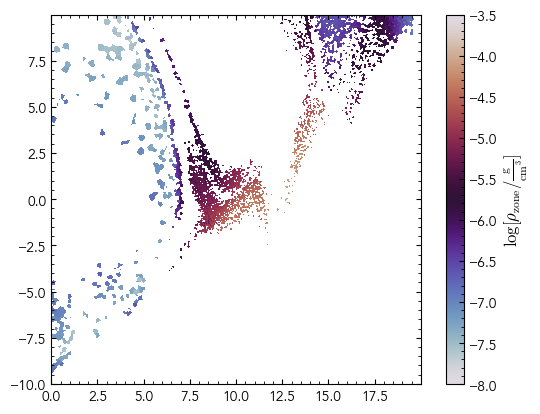

In [4]:
ax, im, _ = snap.plots.slice(
    snap.density * shock_zone,
    # box_size=[-3000, -2000, 1000, 1000],
    box_size=[0, -10, 20, 10],
    res=1024,
    label_latex=r"\rho_{\rm zone}",
    vmin=-8,
    vmax=-3.5,
)
plt.show()

In [5]:
dissipation = snap.dissipation * snap.volume
print("Shock surface dissipation", np.sum(dissipation * result.surface_mask).in_cgs())
print("Shock zone dissipation", np.sum(dissipation * shock_zone).in_cgs())
print("Total dissipation", np.sum(dissipation).in_cgs())

Shock surface dissipation 2.2918053484414442e+42 erg/s
Shock zone dissipation 3.530923966557324e+42 erg/s
Total dissipation 9.625472313391406e+42 erg/s


## Surface slices

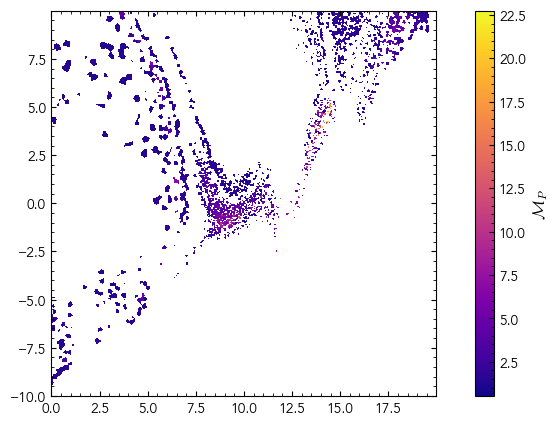

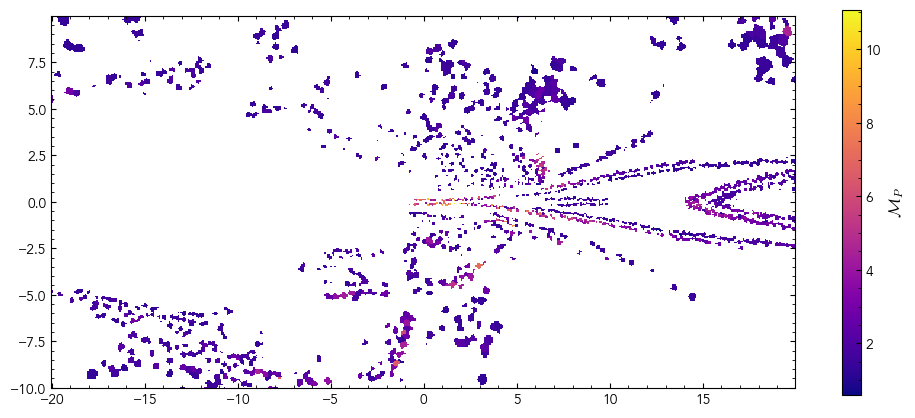

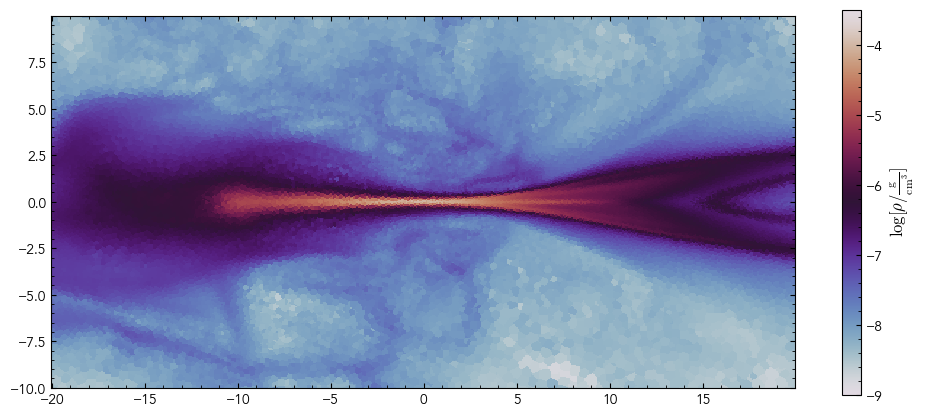

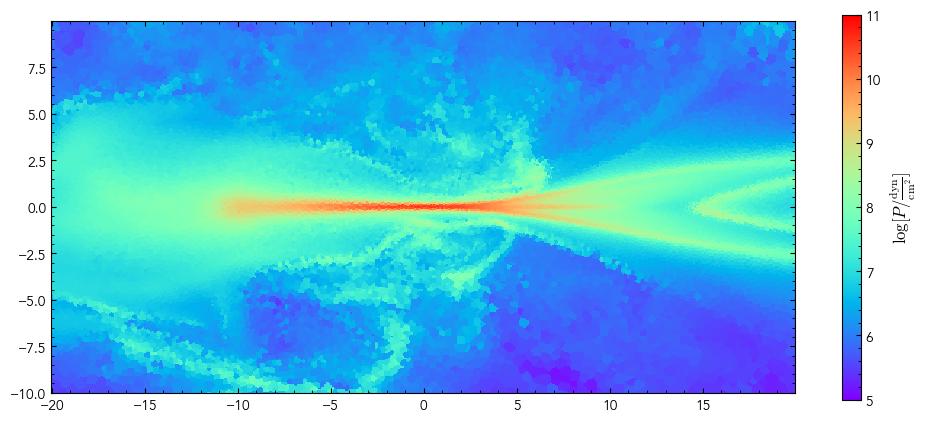

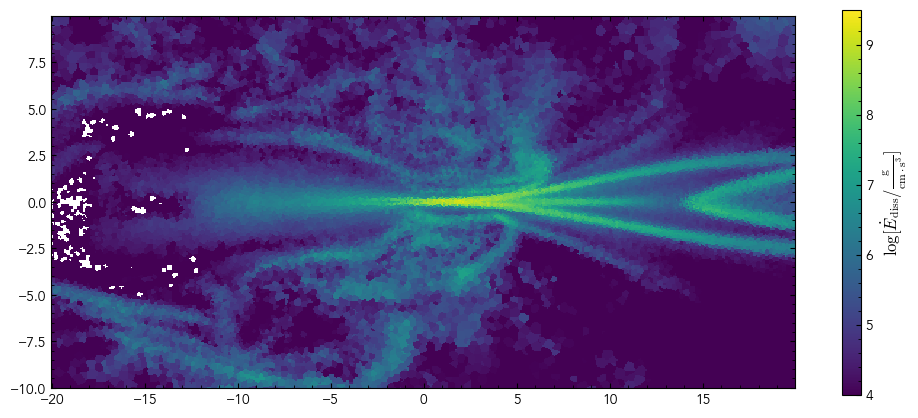

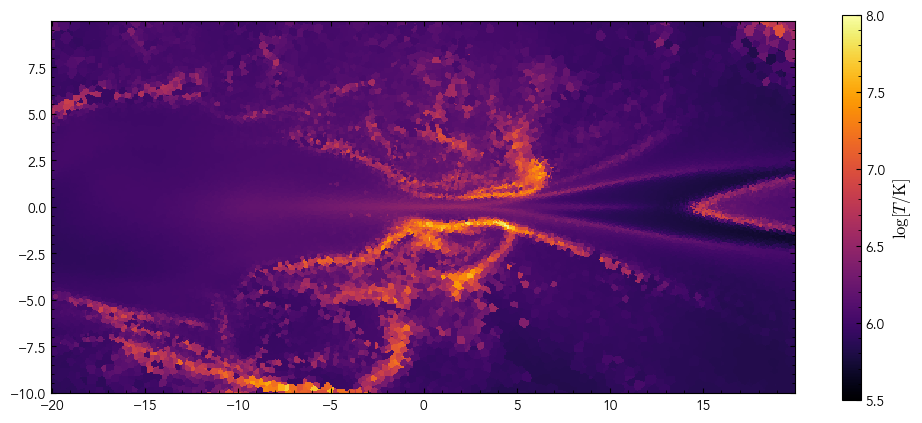

In [5]:
# Shock-surface cells colored by pressure Mach number.
# result.mach_P is per-surface-cell, ordered like np.where(surface_mask)[0], so map
# it onto a full-length field (NaN off the surface). plots.slice hardwires a log
# colorbar, so we call snap.slice and pcolormesh a linear Mach ourselves.
mach_P_field = np.full(len(snap), np.nan)
mach_P_field[result.surface_mask] = result.mach_P


def mach_slice(ax, box, plane="xy", slice_coord=0):
    sliced, xs, ys = snap.slice(
        mach_P_field, res=512, box_size=box, plane=plane, slice_coord=slice_coord
    )
    xg, yg = np.meshgrid(xs, ys, indexing="ij")
    im = ax.pcolormesh(xg, yg, sliced, cmap="plasma")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label=r"$\mathcal{M}_P$")


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mach_slice(ax, box=[0, -10, 20, 10])
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
mach_slice(ax, box=[-20, -10, 20, 10], plane="yz", slice_coord=13)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    "density",
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    label_latex=r"\rho",
    # vmin=37,
)
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    "pressure",
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    label_latex=r"P",
    cmap="rainbow",
)
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    snap.dissipation,
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    vmin=4,
)
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    snap.temperature,
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    cmap="inferno",
    label_latex=r"T",
    # vmin=37,
)
plt.show()

## Mach number

In [ ]:
# Quick diagnostics — helps catch unit/scale surprises
for M, label in zip([result.mach_T, result.mach_P, result.mach_rho], ["T", "P", "rho"]):
    finite = M[np.isfinite(M)]
    print(
        f"M_{label:3s}  n={len(M):5d}  finite={len(finite):5d}  "
        f"min={finite.min():.2f}  med={np.median(finite):.2f}  max={finite.max():.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, M, label in zip(
    axes, [result.mach_T, result.mach_P, result.mach_rho], ["T", "P", r"\rho"]
):
    finite = M[np.isfinite(M)]
    lo, hi = max(1, M.min()), M.max()
    bins = np.linspace(lo, hi, 50)
    ax.hist(finite, bins=bins, color="steelblue", edgecolor="none")
    ax.axvline(
        np.median(finite),
        color="tomato",
        lw=1.5,
        label=f"median = {np.median(finite):.2f}",
    )
    ax.set_xlabel(f"$\\mathcal{{M}}$ (from $\\Delta {label}$)")
    ax.set_ylabel("count")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.suptitle("Shock Mach number distributions")
plt.tight_layout()
plt.show()

## X-Y surface

In [ ]:
# ---- Change the box here; all panels use it. [x_lo, y_lo, x_hi, y_hi] ----
box = [-800, -200, -500, 200, 200, 500]
nbins = 300

x, y = snap.X, snap.Y  # cell-centre coords in code length units
x_surf = np.asarray(x[result.surface_mask])
y_surf = np.asarray(y[result.surface_mask])

x_edges = np.linspace(box[0], box[3], nbins)
y_edges = np.linspace(box[1], box[4], nbins)

fig, (ax_rho, ax_shock, ax_diss) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Top: density projection of the box (column-integrated along Z).
snap.plots.projection(
    "density",
    box_size=box,
    res=512,
    label_latex=r"\rho",
    ax=ax_rho,
)

# Middle: shock-surface cells binned in X-Y, collapsed along Z.
_, _, _, im = ax_shock.hist2d(
    x_surf, y_surf, bins=[x_edges, y_edges], cmap="inferno", norm=LogNorm()
)
ax_shock.set_aspect("equal")
ax_shock.set_ylabel(f"$Y$ [{y.units}]")
ax_shock.set_title(f"Shock-surface cells ({result.surface_mask.sum():,} in box)")
fig.colorbar(im, ax=ax_shock, label="shock-surface cell count")

# Bottom: dissipation projection of the same box (column-integrated along Z).
snap.plots.projection(
    snap.dissipation,
    box_size=box,
    res=512,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    ax=ax_diss,
)
ax_diss.set_xlabel(f"$X$ [{x.units}]")

plt.tight_layout()
plt.show()

## X-Z surface

In [ ]:
# ---- Change the box here; all panels use it. [x_lo, z_lo, x_hi, z_hi] ----
box = [-800, -800, -200, 200, 800, 200]
nbins = 300

x, z = snap.X, snap.Z  # cell-centre coords in code length units
x_surf = np.asarray(x[result.surface_mask])
z_surf = np.asarray(z[result.surface_mask])

x_edges = np.linspace(box[0], box[3], nbins)
z_edges = np.linspace(box[2], box[5], nbins)

fig, (ax_rho, ax_shock, ax_diss) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Top: density projection of the box (column-integrated along Y).
snap.plots.projection(
    "density",
    box_size=box,
    plane="xz",
    res=512,
    label_latex=r"\rho",
    ax=ax_rho,
)

# Middle: shock-surface cells binned in X-Z, collapsed along Y.
_, _, _, im = ax_shock.hist2d(
    x_surf, z_surf, bins=[x_edges, z_edges], cmap="inferno", norm=LogNorm()
)
ax_shock.set_aspect("equal")
ax_shock.set_ylabel(f"$Z$ [{z.units}]")
ax_shock.set_title(f"Shock-surface cells ({result.surface_mask.sum():,} in box)")
fig.colorbar(im, ax=ax_shock, label="shock-surface cell count")

# Bottom: dissipation projection of the same box (column-integrated along Y).
snap.plots.projection(
    snap.dissipation,
    box_size=box,
    plane="xz",
    res=512,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    ax=ax_diss,
)
ax_diss.set_xlabel(f"$X$ [{x.units}]")

plt.tight_layout()
plt.show()